In [1]:
import scanpy as sc
sc.settings.verbosity = 3

# adata_path = '/HDD1/xueweizhi/velocity_benchmark_data/dyngen_batch/general/dataset.h5ad'
adata_path = '/HDD1/xueweizhi/velocity_benchmark_data/batch_simu/dataset_2.h5ad'
adata = sc.read_h5ad(adata_path)
adata

AnnData object with n_obs × n_vars = 6000 × 435
    obs: 'step_ix', 'simulation_i', 'sim_time', 'from', 'to', 'percentage', 'progress', 'direction', 'rho', 'group', 'parent', 'x', 'y', 'Cluster', 'batch'
    obsm: 'X_coord', 'dimred', 'spatial'
    layers: 'counts_protein', 'counts_spliced', 'counts_unspliced', 'logcounts', 'spliced', 'unspliced'

In [3]:
import anndata as ad

adata_spliced = ad.AnnData(adata.layers["spliced"])
adata_spliced.var.index = adata.var.index
adata_unspliced = ad.AnnData(adata.layers["unspliced"])
adata_unspliced.var.index = adata.var.index

sc.pp.normalize_total(adata_spliced)
sc.pp.log1p(adata_spliced)
sc.pp.normalize_total(adata_unspliced)
sc.pp.log1p(adata_unspliced)

sc.pp.highly_variable_genes(adata_spliced, n_top_genes=2000) # 以spliced的高变化基因为准
hvg_gene_list = list(adata_spliced.var[adata_spliced.var.highly_variable].index) 

adata = adata[:, hvg_gene_list]
adata.layers["spliced"] = adata_spliced[:, hvg_gene_list].X
adata.layers["unspliced"] = adata_unspliced[:, hvg_gene_list].X

normalizing counts per cell
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)
If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
`n_top_genes` > `adata.n_var`, returning all genes.
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


In [2]:
import scvelo as scv

scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=2000)

2025-02-10 21:29:27.899337: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-10 21:29:27.914290: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-10 21:29:27.931999: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-10 21:29:27.937432: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-10 21:29:27.950636: I tensorflow/core/platform/cpu_feature_guar

Filtered out 57 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Skip filtering by dispersion since number of variables are less than `n_top_genes`.
Logarithmized X.


/home/xueweizhi/miniconda3/envs/scgen/lib/python3.9/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


分开去批次

In [11]:
import anndata as ad

adata_spliced = ad.AnnData(adata.layers["spliced"], obs=adata.obs)
adata_unspliced = ad.AnnData(adata.layers["unspliced"], obs=adata.obs)

In [12]:
import scib

corrected_adata_spliced = scib.ig.scgen(adata_spliced, batch='batch', cell_type='progress', epochs=10)
corrected_adata_unspliced = scib.ig.scgen(adata_unspliced, batch='batch', cell_type='progress', epochs=10)

GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7,8,9]


Epoch 1/10:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 2/10:  10%|█         | 1/10 [00:01<00:11,  1.31s/it, loss=128, v_num=1]

/home/xueweizhi/miniconda3/envs/scgen/lib/python3.9/site-packages/torchmetrics/utilities/prints.py:32: DeprecationWarning: This property will be removed in 2.0.0. Use `Metric.updated_called` instead.
  return fn(*args, **kwargs)
/home/xueweizhi/miniconda3/envs/scgen/lib/python3.9/site-packages/torchmetrics/utilities/prints.py:32: DeprecationWarning: This property will be removed in 2.0.0. Use `Metric.updated_called` instead.
  return fn(*args, **kwargs)


Epoch 3/10:  20%|██        | 2/10 [00:02<00:10,  1.29s/it, loss=115, v_num=1]

...

Epoch 10/10:  90%|█████████ | 9/10 [00:11<00:01,  1.27s/it, loss=45.5, v_num=1]

/home/xueweizhi/miniconda3/envs/scgen/lib/python3.9/site-packages/torchmetrics/utilities/prints.py:32: DeprecationWarning: This property will be removed in 2.0.0. Use `Metric.updated_called` instead.
  return fn(*args, **kwargs)
/home/xueweizhi/miniconda3/envs/scgen/lib/python3.9/site-packages/torchmetrics/utilities/prints.py:32: DeprecationWarning: This property will be removed in 2.0.0. Use `Metric.updated_called` instead.
  return fn(*args, **kwargs)


Epoch 10/10: 100%|██████████| 10/10 [00:12<00:00,  1.27s/it, loss=44, v_num=1]  

/home/xueweizhi/miniconda3/envs/scgen/lib/python3.9/site-packages/torchmetrics/utilities/prints.py:32: DeprecationWarning: This property will be removed in 2.0.0. Use `Metric.updated_called` instead.
  return fn(*args, **kwargs)
/home/xueweizhi/miniconda3/envs/scgen/lib/python3.9/site-packages/torchmetrics/utilities/prints.py:32: DeprecationWarning: This property will be removed in 2.0.0. Use `Metric.updated_called` instead.
  return fn(*args, **kwargs)



INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


In [13]:
corrected_S = corrected_adata_spliced.X
corrected_U = corrected_adata_unspliced.X
adata_corr = ad.AnnData(corrected_S, obs=adata.obs)
adata_corr.layers["spliced"] = corrected_S
adata_corr.layers["unspliced"] = corrected_U
adata_corr

AnnData object with n_obs × n_vars = 6000 × 378
    obs: 'step_ix', 'simulation_i', 'sim_time', 'from', 'to', 'percentage', 'progress', 'direction', 'rho', 'group', 'parent', 'x', 'y', 'Cluster', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts'
    layers: 'spliced', 'unspliced'

保持比例关系去批次

In [12]:
import numpy as np

M = np.array(adata.layers["spliced"].todense() + adata.layers["unspliced"].todense())
masked_M = (M>0)*M + (M==0)
R = np.array(adata.layers["spliced"].todense())/masked_M

In [13]:
import scib
import anndata as ad

adata_sum = ad.AnnData(M, obs=adata.obs)
corrected_adata_sum = scib.ig.scgen(adata_sum, batch='batch', cell_type='progress', epochs=10)

/home/xueweizhi/miniconda3/envs/scgen/lib/python3.9/site-packages/scvi/model/base/_training_mixin.py:67: UserWarning: max_epochs=10 is less than n_epochs_kl_warmup=400. The max_kl_weight will not be reached during training.
  warnings.warn(
GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7,8,9]


Training:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 2/10:  10%|█         | 1/10 [00:01<00:11,  1.27s/it, loss=202, v_num=1]

/home/xueweizhi/miniconda3/envs/scgen/lib/python3.9/site-packages/torchmetrics/utilities/prints.py:32: DeprecationWarning: This property will be removed in 2.0.0. Use `Metric.updated_called` instead.
  return fn(*args, **kwargs)
/home/xueweizhi/miniconda3/envs/scgen/lib/python3.9/site-packages/torchmetrics/utilities/prints.py:32: DeprecationWarning: This property will be removed in 2.0.0. Use `Metric.updated_called` instead.
  return fn(*args, **kwargs)


Epoch 3/10:  20%|██        | 2/10 [00:02<00:10,  1.27s/it, loss=179, v_num=1]

...

/home/xueweizhi/miniconda3/envs/scgen/lib/python3.9/site-packages/torchmetrics/utilities/prints.py:32: DeprecationWarning: This property will be removed in 2.0.0. Use `Metric.updated_called` instead.
  return fn(*args, **kwargs)
/home/xueweizhi/miniconda3/envs/scgen/lib/python3.9/site-packages/torchmetrics/utilities/prints.py:32: DeprecationWarning: This property will be removed in 2.0.0. Use `Metric.updated_called` instead.
  return fn(*args, **kwargs)


Epoch 10/10: 100%|██████████| 10/10 [00:12<00:00,  1.24s/it, loss=139, v_num=1]

/home/xueweizhi/miniconda3/envs/scgen/lib/python3.9/site-packages/torchmetrics/utilities/prints.py:32: DeprecationWarning: This property will be removed in 2.0.0. Use `Metric.updated_called` instead.
  return fn(*args, **kwargs)
/home/xueweizhi/miniconda3/envs/scgen/lib/python3.9/site-packages/torchmetrics/utilities/prints.py:32: DeprecationWarning: This property will be removed in 2.0.0. Use `Metric.updated_called` instead.
  return fn(*args, **kwargs)
/home/xueweizhi/miniconda3/envs/scgen/lib/python3.9/site-packages/scgen/_scgen.py:268: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  all_shared_ann = AnnData.concatenate(



INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/home/xueweizhi/miniconda3/envs/scgen/lib/python3.9/site-packages/scgen/_scgen.py:286: ImplicitModificationWarning: Setting element `.obsm['latent']` of view, initializing view as actual.
  corrected.obsm["latent"] = all_shared_ann.X


In [14]:
corrected_M = corrected_adata_sum.X
corrected_S = corrected_M * R
corrected_U = corrected_M * (1-R)
adata_corr = ad.AnnData(corrected_S, obs=adata.obs)
adata_corr.layers["spliced"] = corrected_S
adata_corr.layers["unspliced"] = corrected_U
adata_corr

AnnData object with n_obs × n_vars = 6000 × 378
    obs: 'step_ix', 'simulation_i', 'sim_time', 'from', 'to', 'percentage', 'progress', 'direction', 'rho', 'group', 'parent', 'x', 'y', 'Cluster', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts'
    layers: 'spliced', 'unspliced'

In [15]:
adata_corr.X

array([[ 0.        ,  0.        ,  0.        , ...,  9.60715771,
         0.        ,  6.25030184],
       [ 1.92592192,  0.        ,  5.21992493, ...,  1.14527916,
         0.        ,  0.79059158],
       [ 3.99128048,  0.        ,  1.52827287, ..., 11.80822057,
        -0.        ,  6.38109779],
       ...,
       [ 1.423419  ,  0.06348823,  1.89600225, ...,  4.19797549,
         1.20257652,  2.21926818],
       [ 1.00284887,  0.06319271,  1.4329015 , ...,  4.78342176,
         0.87351119,  1.33698366],
       [ 2.45905399,  0.        ,  2.24811331, ...,  6.77918816,
         2.18388367,  1.49482346]])

In [ ]:
adata_corr.write_h5ad('/HDD1/xueweizhi/velocity_benchmark_data/batch_simu/dataset_2_scgen.h5ad')

In [46]:
sc.pp.normalize_per_cell(adata, counts_per_cell_after=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key='batch')
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.tsne(adata)

normalizing by total count per cell
    finished (0:00:00): normalized adata.X and added    'n_counts', counts per cell before normalization (adata.obs)
If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
`n_top_genes` > `adata.n_var`, returning all genes.
`n_top_genes` > `adata.n_var`, returning all genes.
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    on highly variable genes
    with n_comps=50


/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:226: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]
/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:226: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]
/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:508: FutureWarning: The provided callable <funct

    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:09)
computing tSNE
    using 'X_pca' with n_pcs = 50
    using sklearn.manifold.TSNE
    finished: added
    'X_tsne', tSNE coordinates (adata.obsm) (0:00:41)


/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


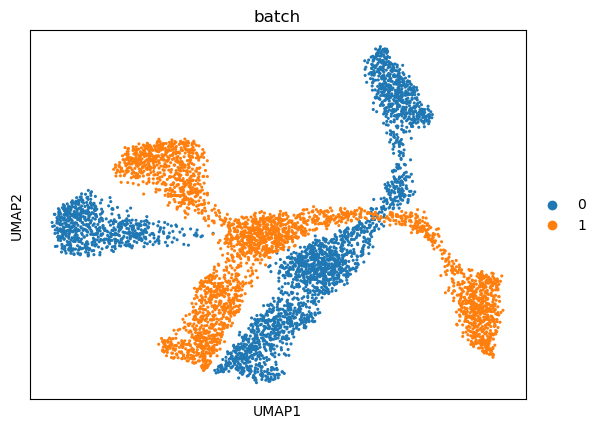

/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


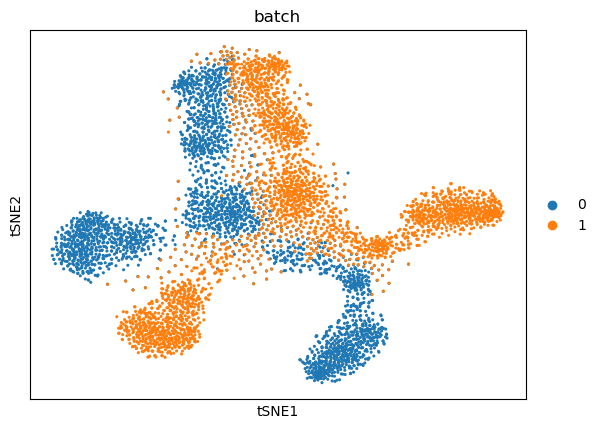

In [47]:
sc.pl.umap(adata, color='batch')
sc.pl.tsne(adata, color='batch')

拼接去批次

In [3]:
import anndata
import numpy as np

U = adata.layers['unspliced']
S = adata.layers['spliced']

if 'toarray' in dir(U):
    U = U.toarray()
    S = S.toarray()

X_all = np.concatenate((U,S),axis = 1)

adata_aggr = anndata.AnnData(X=X_all)
adata_aggr.var_names = [gene+'_u' for gene in adata.var_names.to_list()]+adata.var_names.to_list()
adata_aggr.obs = adata.obs
adata_aggr

AnnData object with n_obs × n_vars = 6000 × 756
    obs: 'step_ix', 'simulation_i', 'sim_time', 'from', 'to', 'percentage', 'progress', 'direction', 'rho', 'group', 'parent', 'x', 'y', 'Cluster', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts'

In [5]:
import scib

corrected_adata_aggr = scib.ig.scgen(adata_aggr, batch='batch', cell_type='progress', epochs=10)

/home/xueweizhi/miniconda3/envs/scgen/lib/python3.9/site-packages/scvi/model/base/_training_mixin.py:67: UserWarning: max_epochs=10 is less than n_epochs_kl_warmup=400. The max_kl_weight will not be reached during training.
  warnings.warn(
GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7,8,9]


Epoch 1/10:   0%|          | 0/10 [00:00<?, ?it/s]

/home/xueweizhi/miniconda3/envs/scgen/lib/python3.9/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)


Epoch 2/10:  10%|█         | 1/10 [00:01<00:13,  1.52s/it, loss=215, v_num=1]

/home/xueweizhi/miniconda3/envs/scgen/lib/python3.9/site-packages/torchmetrics/utilities/prints.py:32: DeprecationWarning: This property will be removed in 2.0.0. Use `Metric.updated_called` instead.
  return fn(*args, **kwargs)
/home/xueweizhi/miniconda3/envs/scgen/lib/python3.9/site-packages/torchmetrics/utilities/prints.py:32: DeprecationWarning: This property will be removed in 2.0.0. Use `Metric.updated_called` instead.
  return fn(*args, **kwargs)


...

/home/xueweizhi/miniconda3/envs/scgen/lib/python3.9/site-packages/torchmetrics/utilities/prints.py:32: DeprecationWarning: This property will be removed in 2.0.0. Use `Metric.updated_called` instead.
  return fn(*args, **kwargs)
/home/xueweizhi/miniconda3/envs/scgen/lib/python3.9/site-packages/torchmetrics/utilities/prints.py:32: DeprecationWarning: This property will be removed in 2.0.0. Use `Metric.updated_called` instead.
  return fn(*args, **kwargs)


Epoch 10/10: 100%|██████████| 10/10 [00:12<00:00,  1.25s/it, loss=164, v_num=1]

/home/xueweizhi/miniconda3/envs/scgen/lib/python3.9/site-packages/torchmetrics/utilities/prints.py:32: DeprecationWarning: This property will be removed in 2.0.0. Use `Metric.updated_called` instead.
  return fn(*args, **kwargs)
/home/xueweizhi/miniconda3/envs/scgen/lib/python3.9/site-packages/torchmetrics/utilities/prints.py:32: DeprecationWarning: This property will be removed in 2.0.0. Use `Metric.updated_called` instead.
  return fn(*args, **kwargs)


/home/xueweizhi/miniconda3/envs/scgen/lib/python3.9/site-packages/scgen/_scgen.py:268: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  all_shared_ann = AnnData.concatenate(
/home/xueweizhi/miniconda3/envs/scgen/lib/python3.9/site-packages/scgen/_scgen.py:286: ImplicitModificationWarning: Setting element `.obsm['latent']` of view, initializing view as actual.
  corrected.obsm["latent"] = all_shared_ann.X


INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


In [6]:
U = corrected_adata_aggr[:, corrected_adata_aggr.var_names.str.endswith('_u')].X
S = corrected_adata_aggr[:, ~corrected_adata_aggr.var_names.str.endswith('_u')].X
adata_corr = anndata.AnnData(X=S)
adata_corr.layers['unspliced'] = U
adata_corr.layers['spliced'] = S
adata_corr.obs = adata.obs
adata_corr.var_names = adata.var_names
adata_corr

AnnData object with n_obs × n_vars = 6000 × 378
    obs: 'step_ix', 'simulation_i', 'sim_time', 'from', 'to', 'percentage', 'progress', 'direction', 'rho', 'group', 'parent', 'x', 'y', 'Cluster', 'batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts'
    layers: 'unspliced', 'spliced'

In [7]:
adata_corr.write_h5ad('/HDD1/xueweizhi/velocity_benchmark_data/batch_simu/dataset_2_scgen_cat.h5ad')

Scanorama

In [3]:
batches = adata_aggr.obs['batch'].cat.categories.tolist()
all_data = {}
for batch in batches:
    all_data[batch] = adata_aggr[adata_aggr.obs['batch'] == batch]
all_data

{'0': View of AnnData object with n_obs × n_vars = 3000 × 870
     obs: 'step_ix', 'simulation_i', 'sim_time', 'from', 'to', 'percentage', 'progress', 'direction', 'rho', 'group', 'parent', 'x', 'y', 'Cluster', 'batch',
 '1': View of AnnData object with n_obs × n_vars = 3000 × 870
     obs: 'step_ix', 'simulation_i', 'sim_time', 'from', 'to', 'percentage', 'progress', 'direction', 'rho', 'group', 'parent', 'x', 'y', 'Cluster', 'batch'}

In [4]:
for adata_i in all_data.values():
    sc.pp.normalize_per_cell(adata_i, counts_per_cell_after=1e4)
    sc.pp.log1p(adata_i)
    sc.pp.highly_variable_genes(adata_i, flavor='seurat', n_top_genes=2000)
adatas = list(all_data.values())

normalizing by total count per cell
    finished (0:00:00): normalized adata.X and added    'n_counts', counts per cell before normalization (adata.obs)
If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
`n_top_genes` > `adata.n_var`, returning all genes.
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
normalizing by total count per cell
    finished (0:00:00): normalized adata.X and added    'n_counts', counts per cell before normalization (adata.obs)
If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
`n_top_genes` > `adata.n_var`, returning all genes.
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (ada

/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/preprocessing/_simple.py:523: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[key_n_counts] = counts_per_cell
/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:226: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]
/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:279: UserWarning: `n_top_genes` > number of normalized dispersions, returning all genes with normalized dispersions.
  warnings.warn(
/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/sc

In [5]:
import scanorama

adatas_corr = scanorama.correct_scanpy(adatas)
adata_corr = sc.concat(adatas_corr)
adata_corr

Found 870 genes among all datasets
[[0.         0.99833333]
 [0.         0.        ]]
Processing datasets (0, 1)


AnnData object with n_obs × n_vars = 6000 × 870
    obs: 'step_ix', 'simulation_i', 'sim_time', 'from', 'to', 'percentage', 'progress', 'direction', 'rho', 'group', 'parent', 'x', 'y', 'Cluster', 'batch', 'n_counts'

In [4]:
U = adata_corr[:, adata_corr.var_names.str.endswith('_u')].X
S = adata_corr[:, ~adata_corr.var_names.str.endswith('_u')].X
adata_processed = anndata.AnnData(X=S)
adata_processed.layers['unspliced'] = U
adata_processed.layers['spliced'] = S
adata_processed.obs = adata_corr.obs
adata_processed.var_names = adata_corr.var_names[~adata_corr.var_names.str.endswith('_u')]
adata_processed

NameError: name 'adata_corr' is not defined

In [7]:
adata_processed_path = '/HDD1/xueweizhi/velocity_benchmark_data/batch_simu/dataset_2_Scanorama.h5ad'
adata_processed.write_h5ad(adata_processed_path)

In [22]:
adata_corr.X.toarray()

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.03566457,  0.01339328,  0.03265282, ...,  0.06912765,
         0.06395301, -0.01240137],
       [ 0.00646019, -0.02470612,  0.02257012, ...,  0.00483642,
         0.00072814, -0.01190585],
       [-0.02984414, -0.0223837 , -0.01287761, ...,  0.06545308,
         0.05599518, -0.01028311]])

In [8]:
sc.pp.highly_variable_genes(adata_corr, n_top_genes=2000)
sc.tl.pca(adata_corr)
sc.pp.neighbors(adata_corr)
sc.tl.umap(adata_corr)

If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
`n_top_genes` > `adata.n_var`, returning all genes.
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    on highly variable genes
    with n_comps=50


/home/xueweizhi/miniconda3/envs/scgen/lib/python3.9/site-packages/scanpy/preprocessing/_utils.py:11: RuntimeWarning: overflow encountered in multiply
  mean_sq = np.multiply(X, X).mean(axis=axis, dtype=np.float64)
/home/xueweizhi/miniconda3/envs/scgen/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:218: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/home/xueweizhi/miniconda3/envs/scgen/lib/python3.9/site-packages/pandas/core/dtypes/cast.py:1641: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])
/home/xueweizhi/miniconda3/envs/scgen/lib/python3.9/site-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.o

    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:10)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:10)


/home/xueweizhi/miniconda3/envs/scgen/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


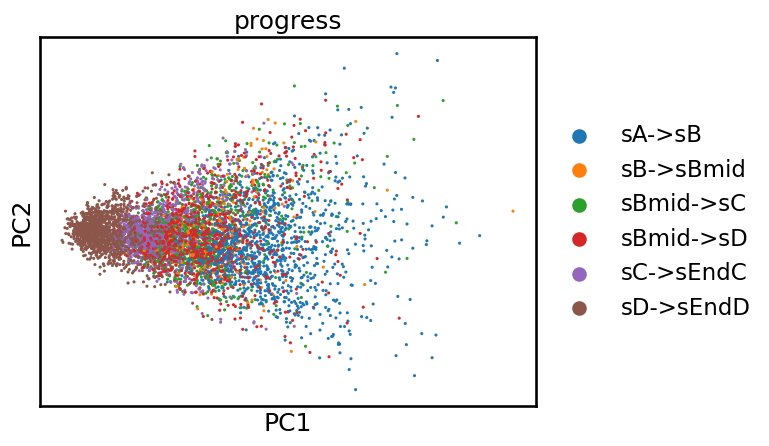

/home/xueweizhi/miniconda3/envs/scgen/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


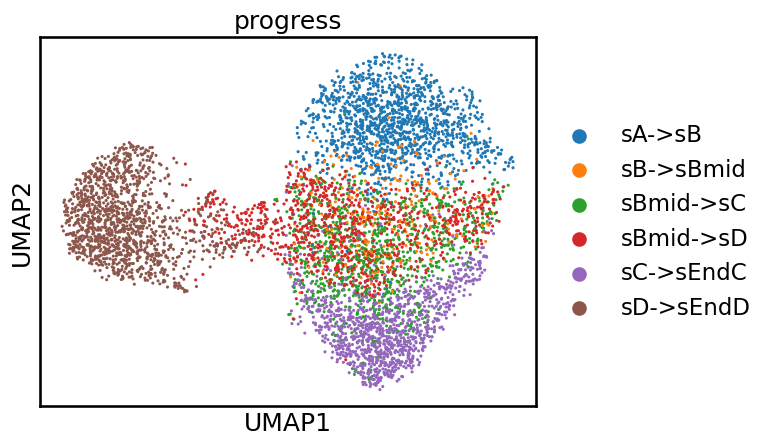

In [9]:
sc.pl.pca(adata_corr, color='progress')
sc.pl.umap(adata_corr, color='progress')

ComBat

In [3]:
sc.pp.normalize_per_cell(adata_aggr, counts_per_cell_after=1e4)
sc.pp.log1p(adata_aggr)
sc.pp.combat(adata_aggr, key='batch')

normalizing by total count per cell
    finished (0:00:00): normalized adata.X and added    'n_counts', counts per cell before normalization (adata.obs)
Standardizing Data across genes.

Found 2 batches

Found 0 numerical variables:
	

Found 8 genes with zero variance.
Fitting L/S model and finding priors



/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/preprocessing/_combat.py:199: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  batch_info = model.groupby(key).indices.values()
/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/preprocessing/_combat.py:95: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  batch_items = model.groupby(batch_key).groups.items()


Finding parametric adjustments

Adjusting data



/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/preprocessing/_combat.py:340: RuntimeWarning: invalid value encountered in divide
  (abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max()
/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/preprocessing/_combat.py:340: RuntimeWarning: divide by zero encountered in divide
  (abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max()


In [5]:
U = adata_aggr[:, adata_aggr.var_names.str.endswith('_u')].X
S = adata_aggr[:, ~adata_aggr.var_names.str.endswith('_u')].X
adata_processed = anndata.AnnData(X=S)
adata_processed.layers['unspliced'] = U
adata_processed.layers['spliced'] = S
adata_processed.obs = adata_aggr.obs
adata_processed.var_names = adata_aggr.var_names[~adata_aggr.var_names.str.endswith('_u')]
adata_processed

AnnData object with n_obs × n_vars = 6000 × 435
    obs: 'step_ix', 'simulation_i', 'sim_time', 'from', 'to', 'percentage', 'progress', 'direction', 'rho', 'group', 'parent', 'x', 'y', 'Cluster', 'batch', 'n_counts'
    layers: 'unspliced', 'spliced'

In [6]:
adata_processed_path = '/HDD1/xueweizhi/velocity_benchmark_data/batch_simu/dataset_2_COMBAT.h5ad'
adata_processed.write_h5ad(adata_processed_path)

In [30]:
sc.pp.highly_variable_genes(adata_aggr, n_top_genes=2000)
sc.tl.pca(adata_aggr)
sc.pp.neighbors(adata_aggr)
sc.tl.umap(adata_aggr)
sc.tl.tsne(adata_aggr)

If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
`n_top_genes` > `adata.n_var`, returning all genes.
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    on highly variable genes
    with n_comps=50


/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:226: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]
/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:279: UserWarning: `n_top_genes` > number of normalized dispersions, returning all genes with normalized dispersions.
  warnings.warn(


    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:08)
computing tSNE
    using 'X_pca' with n_pcs = 50
    using sklearn.manifold.TSNE
    finished: added
    'X_tsne', tSNE coordinates (adata.obsm) (0:00:45)


/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


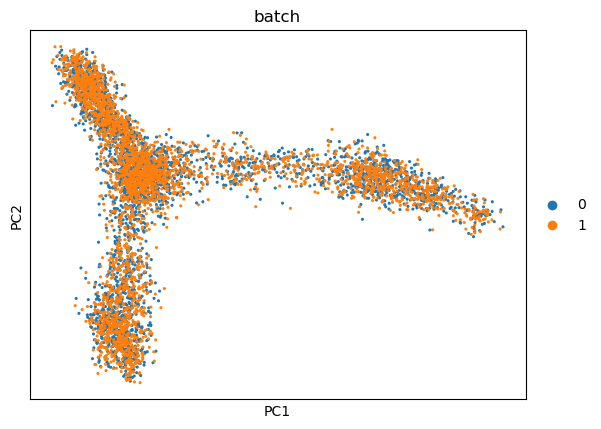

/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


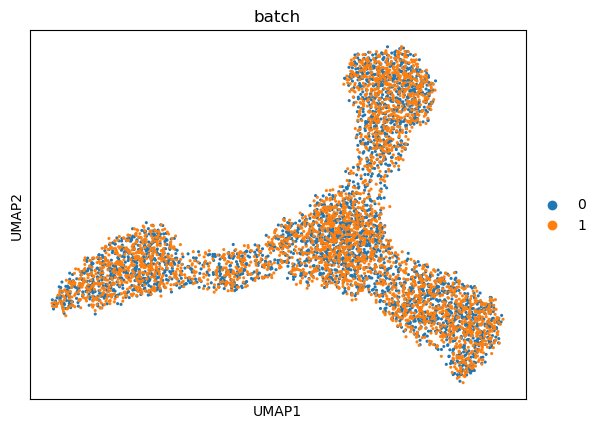

/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


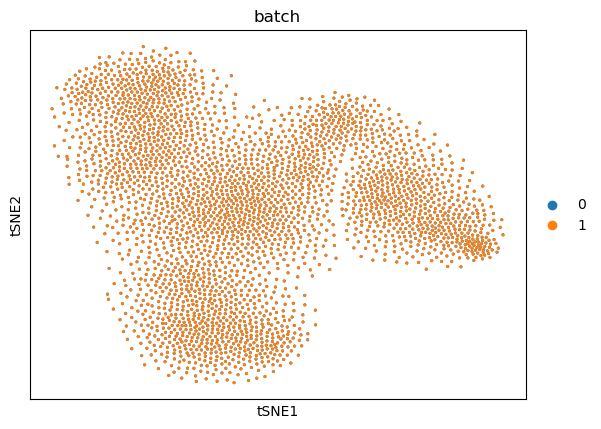

In [31]:
sc.pl.pca(adata_aggr, color='batch')
sc.pl.umap(adata_aggr, color='batch')
sc.pl.tsne(adata_aggr, color='batch')

In [36]:
adata_aggr

AnnData object with n_obs × n_vars = 6000 × 870
    obs: 'step_ix', 'simulation_i', 'sim_time', 'from', 'to', 'percentage', 'progress', 'direction', 'rho', 'group', 'parent', 'x', 'y', 'Cluster', 'batch', 'n_counts'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'tsne', 'batch_colors'
    obsm: 'X_pca', 'X_umap', 'X_tsne'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [38]:
U = adata_aggr.X[:,0:adata_aggr.shape[1]//2]
S = adata_aggr.X[:,adata_aggr.shape[1]//2:]
adata_processed = anndata.AnnData(X=S)
adata_processed.layers['unspliced'] = U
adata_processed.layers['spliced'] = S
adata_processed.var_names = adata_aggr.var_names[adata_aggr.shape[1]//2:]
adata_processed.obs = adata_aggr.obs
adata_processed.X

array([[-1.11044753e-02,  1.17161354e+00, -5.93822710e-04, ...,
         5.56573751e+00, -1.39705773e-02,  5.95536687e+00],
       [ 3.89906965e+00,  1.17161354e+00,  5.11554411e+00, ...,
         3.26268421e+00, -1.39705773e-02,  3.74187549e+00],
       [ 4.77811718e+00,  1.17161354e+00,  4.47673456e+00, ...,
         5.60761539e+00, -1.39705773e-02,  5.65442022e+00],
       ...,
       [ 2.82222815e+00,  2.56415755e+00,  4.13682418e+00, ...,
         4.64400013e+00,  2.83895759e+00,  4.48754534e+00],
       [ 2.94320921e+00,  1.88635063e+00,  3.75012522e+00, ...,
         4.92521700e+00,  2.96088086e+00,  4.03721805e+00],
       [ 4.47976757e+00, -4.73936142e-01,  4.09645011e+00, ...,
         5.12922411e+00,  3.32790416e+00,  3.88492478e+00]])

In [7]:
sc.pp.highly_variable_genes(adata_processed, n_top_genes=2000)
sc.tl.pca(adata_processed)
sc.pp.neighbors(adata_processed)
sc.tl.umap(adata_processed)
sc.tl.tsne(adata_processed)

If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
`n_top_genes` > `adata.n_var`, returning all genes.
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    on highly variable genes
    with n_comps=50


/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:226: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]
/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:279: UserWarning: `n_top_genes` > number of normalized dispersions, returning all genes with normalized dispersions.
  warnings.warn(


    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 50


2025-02-07 10:07:48.787132: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-07 10:07:48.801474: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-07 10:07:48.816976: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-07 10:07:48.821372: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-07 10:07:48.833870: I tensorflow/core/platform/cpu_feature_guar

    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:07)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:08)
computing tSNE
    using 'X_pca' with n_pcs = 50
    using sklearn.manifold.TSNE
    finished: added
    'X_tsne', tSNE coordinates (adata.obsm) (0:00:42)


/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


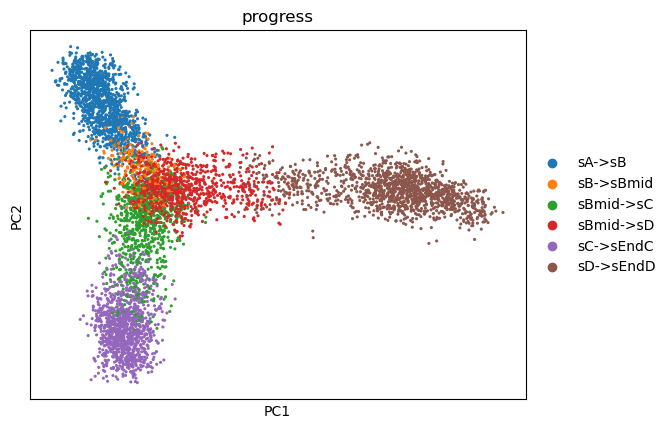

/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


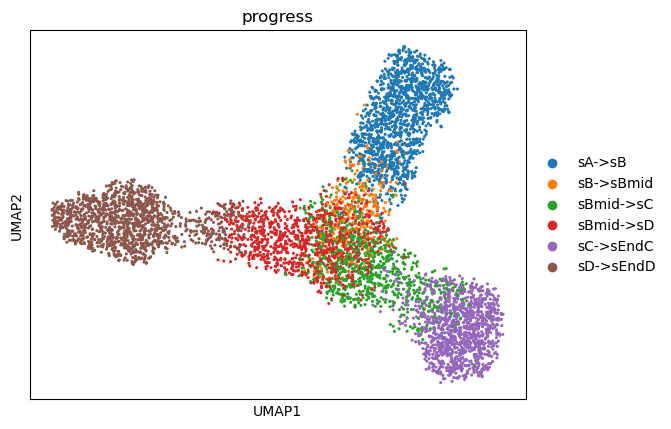

/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


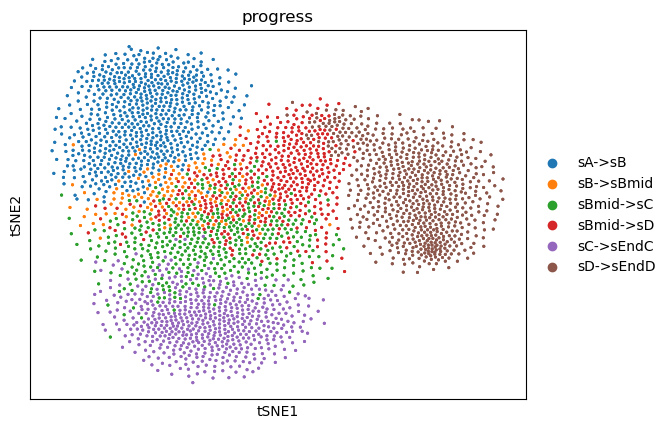

In [9]:
sc.pl.pca(adata_processed, color='progress')
sc.pl.umap(adata_processed, color='progress')
sc.pl.tsne(adata_processed, color='progress')

In [23]:
adata_ref_path = '../logs/scvelo/simulate/dyngen/general/dataset/scvelo_dynamical.h5ad'
adata_ref = sc.read_h5ad(adata_ref_path)
adata_ref

AnnData object with n_obs × n_vars = 3000 × 379
    obs: 'step_ix', 'simulation_i', 'sim_time', 'from', 'to', 'percentage', 'progress', 'direction', 'rho', 'group', 'parent', 'x', 'y', 'Cluster', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'velocity_self_transition', 'root_cells', 'end_points', 'velocity_pseudotime', 'latent_time', 'pred_t'
    var: 'fit_r2', 'fit_alpha', 'fit_beta', 'fit_gamma', 'fit_t_', 'fit_scaling', 'fit_std_u', 'fit_std_s', 'fit_likelihood', 'fit_u0', 'fit_s0', 'fit_pval_steady', 'fit_steady_u', 'fit_steady_s', 'fit_variance', 'fit_alignment_scaling', 'velocity_genes', 'scvelo_dynamical_alpha', 'scvelo_dynamical_beta', 'scvelo_dynamical_gamma'
    uns: 'coord_star', 'log1p', 'neighbors', 'pca', 'progress_colors', 'recover_dynamics', 'velocity_graph', 'velocity_graph_neg', 'velocity_params'
    obsm: 'X_coord', 'X_pca', 'dimred', 'spatial'
    varm: 'PCs', 'loss'
    layers: 'Ms', 'Mu', 'counts_protein', 'counts_spliced', 'counts_

In [24]:
adata_ref.X.toarray()

array([[0.        , 0.        , 0.81456655, ..., 2.1458354 , 0.        ,
        2.283135  ],
       [0.70813495, 1.4086926 , 1.4086926 , ..., 1.1185465 , 0.70813495,
        1.8166158 ],
       [1.5600762 , 1.2545108 , 0.81228983, ..., 2.4001193 , 0.        ,
        1.9831104 ],
       ...,
       [0.32584053, 1.4966612 , 1.1973007 , ..., 1.7267468 , 0.32584053,
        1.4064783 ],
       [0.610361  , 0.9866343 , 0.9866343 , ..., 1.7274036 , 0.81609195,
        1.1322856 ],
       [1.0217285 , 0.46540815, 1.0217285 , ..., 1.8459283 , 0.46540815,
        0.78176606]], dtype=float32)

In [26]:
adata_ref.layers['unspliced'].toarray()

array([[0.        , 0.        , 1.625     , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 2.1010101 , 0.        , ..., 1.05050505, 1.05050505,
        4.2020202 ],
       [1.55223881, 3.10447761, 0.        , ..., 3.10447761, 0.        ,
        0.        ],
       ...,
       [0.        , 1.09473684, 1.09473684, ..., 1.09473684, 0.        ,
        0.72982456],
       [0.4015444 , 0.8030888 , 0.8030888 , ..., 0.4015444 , 0.8030888 ,
        0.8030888 ],
       [0.        , 0.54166667, 0.54166667, ..., 0.54166667, 0.        ,
        0.        ]])